# **Fase 1: PyTorch e EDOs**
**Objetivo:** dominar o *framework* que será usado em PINNs e conectar os gradientes automáticos (*autograds*) com EDOs.

**Conceitos-chave:**

### Sumário

*Etapa 1.1 PyTorch básico*

**Etapa 1.2 `torch.autograd.grad` vs `.backward()`**

**Etapa 1.3 Aproximação de funções**

*Etapa 1.4 Proto-PINN: EDO sem chamar de PINN*

*Mini-projeto 1: Reconstrução de $H(z)$ a partir de dados de cronômetros cósmicos*

## Etapa 1.2 — `torch.autograd.grad` vs. `backward()`

Existe uma diferença notável entre os dois métodos. Enquanto `backward()` retorna o gradiente de um tensor em relação aos parâmetros que os compõe, o `autograd.grad` calcula o gradiente de uma saída em relação a uma entrada.

In [15]:
import torch
import numpy as np

In [14]:
x = torch.tensor([[1.0], [2.0], [3.0], [3.0], [5.0]], requires_grad=True)
y = x**2 + 5 * x - 6

dydx_pesos = torch.ones_like(y)

dydx = torch.autograd.grad(y, x, grad_outputs=dydx_pesos, create_graph=True)
print(f'A derivada de y em relação a x é\n{dydx}.')

d2ydx2 = torch.autograd.grad(dydx, x, grad_outputs=dydx_pesos)
print(f'A derivada segundade y em relação a x é\n{d2ydx2}.')

A derivada de y em relação a x é
(tensor([[ 7.],
        [ 9.],
        [11.],
        [11.],
        [15.]], grad_fn=<AddBackward0>),).
A derivada segundade y em relação a x é
(tensor([[2.],
        [2.],
        [2.],
        [2.],
        [2.]]),).


## Etapa 1.3 — Aproximação de função

Assim como na fase anterior, a ideia central é aproximar funções. Faremos isso usando PyTorch e a classe `Optimizer`.

In [44]:
ndados = 70
x = torch.zeros((70,1))
torch.linspace(0, 4*np.pi, ndados, out=x)
Y = torch.sin(3*x) * torch.exp(-x/2)

neuronios = 64

w1 = torch.randn((1, neuronios), dtype=torch.float, requires_grad=True)
b1 = torch.randn(neuronios, requires_grad=True)

w2 = torch.randn((neuronios, 1), dtype=torch.float, requires_grad=True)
b2 = torch.randn(1, dtype=torch.float, requires_grad=True)

epocas = 10000
eta = 0.0001

optimizer = torch.optim.Adam([w1, b1, w2, b2], lr=eta)

def forward(x, params, activation=None):
    w1, b1, w2, b2 = params

    h1 = x @ w1 + b1

    if activation is not None:
        if activation == 'relu':
            z1 = torch.nn.functional.relu(h1)
        elif activation == 'tanh':
            z1 = torch.nn.functional.tanh(h1)

    y = z1 @ w2 + b2

    return y

for epoca in range(epocas):
    optimizer.zero_grad()

    y = forward(x, [w1, b1, w2, b2], activation='relu')

    loss = torch.nn.functional.mse_loss(y, Y)
    loss.backward()
    optimizer.step()

    if (epoca+1)%500 == 0 or epoca == 0:
        print(30*'-'+f'\nÉpoca {epoca+1}:\n\nLoss = {loss}\n'+30*'-')

------------------------------
Época 1:

Loss = 210.158447265625
------------------------------
------------------------------
Época 500:

Loss = 30.394628524780273
------------------------------
------------------------------
Época 1000:

Loss = 9.557398796081543
------------------------------
------------------------------
Época 1500:

Loss = 6.563466548919678
------------------------------
------------------------------
Época 2000:

Loss = 4.085304260253906
------------------------------
------------------------------
Época 2500:

Loss = 1.6455516815185547
------------------------------
------------------------------
Época 3000:

Loss = 0.7091951370239258
------------------------------
------------------------------
Época 3500:

Loss = 0.23815381526947021
------------------------------
------------------------------
Época 4000:

Loss = 0.11815401911735535
------------------------------
------------------------------
Época 4500:

Loss = 0.07322834432125092
---------------------------

In [35]:
import matplotlib.pyplot as plt

In [45]:
x_modelo = torch.zeros((1000, 1))
torch.linspace(0.0, 4*torch.pi, 1000, out=x_modelo)
y_modelo = forward(x_modelo, [w1, b1, w2, b2], activation='relu')

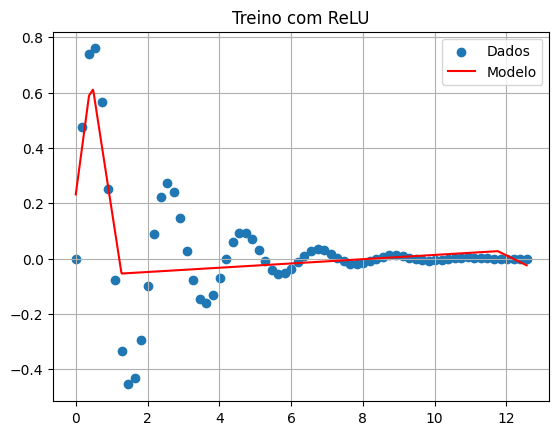

In [33]:
plt.scatter(x, Y, label='Dados')
plt.plot(x_modelo, y_modelo.detach().numpy(), color='red', label='Modelo')
plt.title('Treino com ReLU')
plt.legend()
plt.grid()
plt.show()

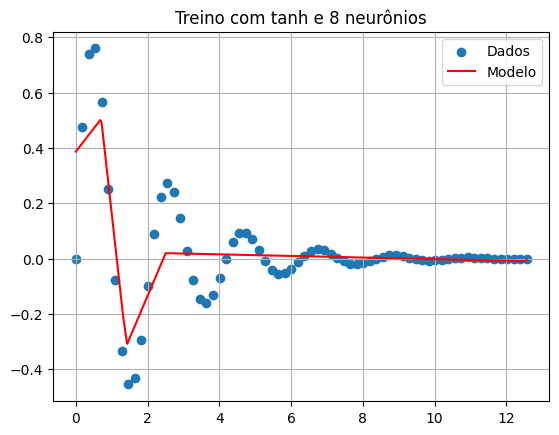

In [38]:
plt.scatter(x, Y, label='Dados')
plt.plot(x_modelo, y_modelo.detach().numpy(), color='red', label='Modelo')
plt.title('Treino com tanh e 8 neurônios')
plt.legend()
plt.grid()
plt.show()

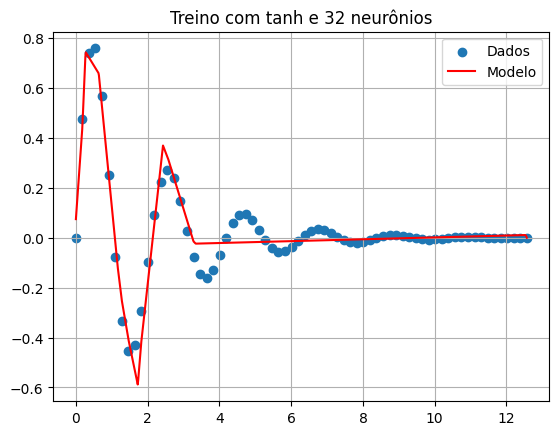

In [41]:
plt.scatter(x, Y, label='Dados')
plt.plot(x_modelo, y_modelo.detach().numpy(), color='red', label='Modelo')
plt.title('Treino com tanh e 32 neurônios')
plt.legend()
plt.grid()
plt.show()

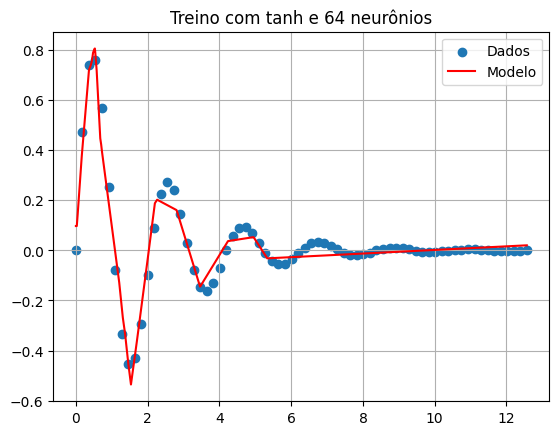

In [46]:
plt.scatter(x, Y, label='Dados')
plt.plot(x_modelo, y_modelo.detach().numpy(), color='red', label='Modelo')
plt.title('Treino com tanh e 64 neurônios')
plt.legend()
plt.grid()
plt.show()